In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("titanic_data_updated.csv")

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Analytical View of a Dataset

In [9]:
df.shape

print(f"Total potential features: {df.shape[1]}")
print(f"Total sample data: {df.shape[0]}")

Total potential features: 12
Total sample data: 891


In [11]:
df.head(10)
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
22,23,yes,third,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
558,559,yes,first,"Taussig, Mrs. Emil (Tillie Mandelbaum)",female,39.0,1,1,110413,79.6500,E67,S
785,786,no,third,"Harmer, Mr. Abraham (David Lishin)",male,25.0,0,0,374887,7.2500,NaN,S
204,205,yes,third,"Cohen, Mr. Gurshon ""Gus""",male,18.0,0,0,A/5 3540,8.0500,NaN,S
309,310,yes,first,"Francatelli, Miss. Laura Mabel",female,30.0,0,0,PC 17485,56.9292,E36,C
529,530,no,second,"Hocking, Mr. Richard George",male,23.0,2,1,29104,11.5000,NaN,S
555,556,no,first,"Wright, Mr. George",male,62.0,0,0,113807,26.5500,NaN,S
599,600,yes,first,"Duff Gordon, Sir. Cosmo Edmund (""Mr Morgan"")",male,49.0,1,0,PC 17485,56.9292,A20,C
800,801,no,second,"Ponesell, Mr. Martin",male,34.0,0,0,250647,13.0000,NaN,S
265,266,no,second,"Reeves, Mr. David",male,36.0,0,0,C.A. 17248,10.5000,NaN,S


## Feature Screening

# 3. Feature Screening

In [12]:
# missing

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
# checking duplicates

df.duplicated().sum()

df.drop_duplicates(inplace=True)

# 4. Statistical Profiling

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    object 
 2   Pclass       891 non-null    object 
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(7)
memory usage: 83.7+ KB


In [16]:
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,29.699118,0.523008,0.381594,32.204208
std,257.353842,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,38.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


# 5. Univariate Analysis( Categorical Value Analysis -1 )

<Axes: xlabel='Survived', ylabel='count'>

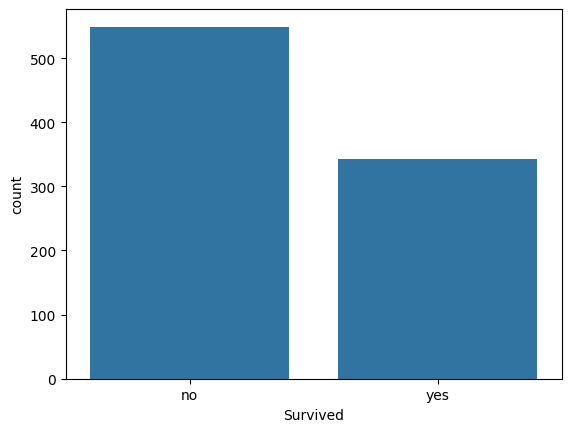

In [17]:
sns.countplot(data = df, x=df['Survived'])

In [18]:
(df['Survived'].value_counts() / len(df)) * 100

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64

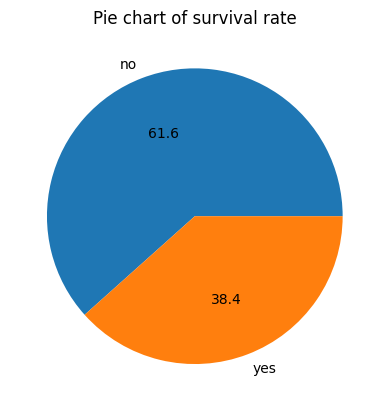

In [23]:
servived_count = df['Survived'].value_counts()

servived_label = df['Survived'].unique()

plt.pie(servived_count, labels = servived_label, autopct="%1.1f")
plt.title("Pie chart of survival rate")
plt.show()

# 6. Univariate Analysis( Categorical Value Analysis -2)

<Axes: xlabel='Pclass', ylabel='count'>

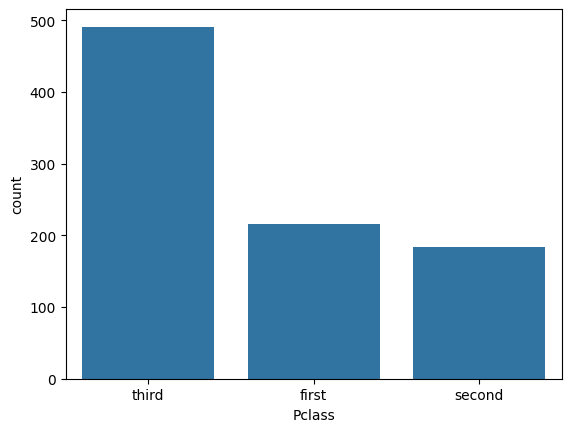

In [24]:
sns.countplot(data = df, x = df['Pclass'])

In [25]:
(df['Pclass'].value_counts() / len(df)) * 100

Pclass
third     55.106622
first     24.242424
second    20.650954
Name: count, dtype: float64

<Axes: xlabel='Sex', ylabel='count'>

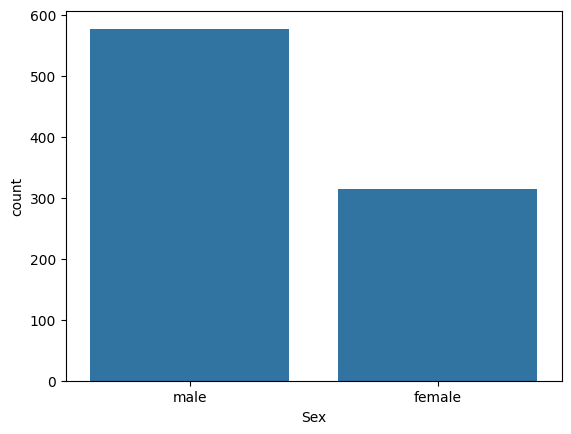

In [26]:
sns.countplot(data=df, x = df['Sex'])

In [27]:
(df['Sex'].value_counts() / len(df)) * 100

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

<Axes: xlabel='Embarked', ylabel='count'>

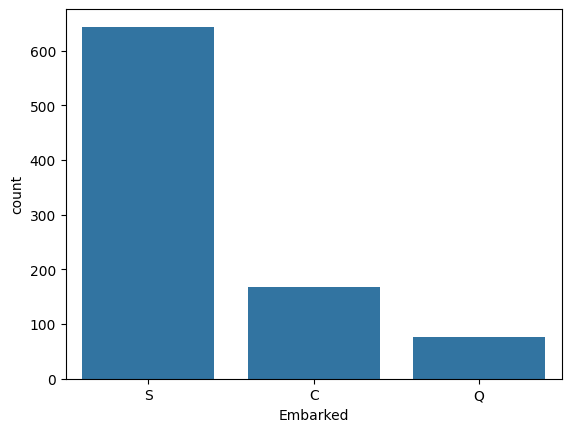

In [28]:
sns.countplot(data = df, x=df['Embarked'])

In [29]:
(df['Embarked'].value_counts() / len(df)) * 100

Embarked
S    72.278339
C    18.855219
Q     8.641975
Name: count, dtype: float64

# 7.Univariate Analysis ( Numerical Column Analysis - 1)

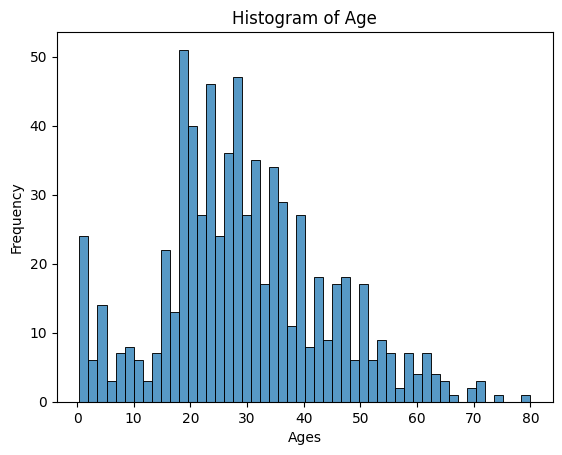

In [30]:
sns.histplot(df['Age'], bins=50)

plt.title("Histogram of Age")
plt.xlabel("Ages")
plt.ylabel("Frequency")

plt.show()

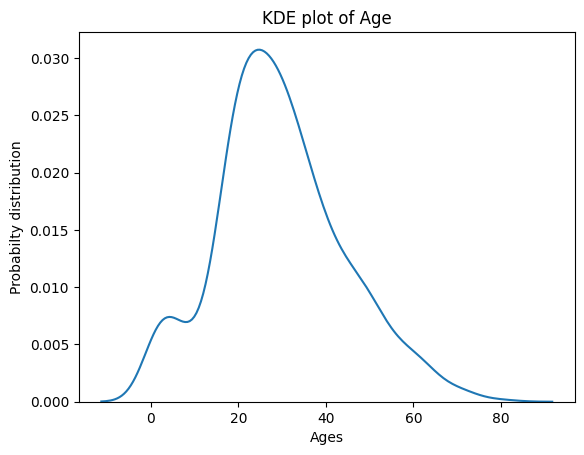

In [31]:
sns.kdeplot(df['Age'])

plt.title("KDE plot of Age")
plt.xlabel("Ages")
plt.ylabel("Probabilty distribution")

plt.show()

# 8.Univariate Analysis ( Numerical Column Analysis - 2)

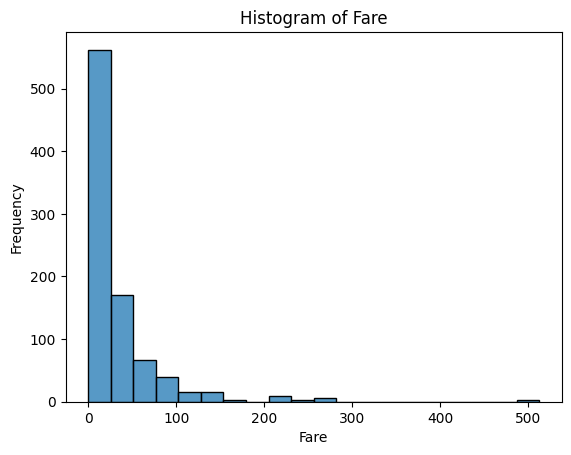

In [33]:
sns.histplot(df['Fare'], bins=20)

plt.title("Histogram of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

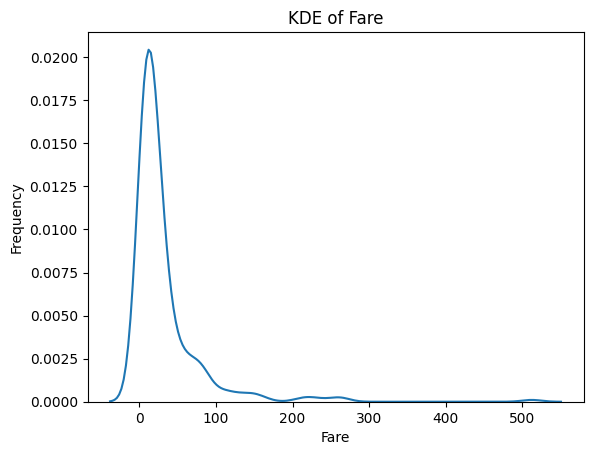

In [34]:
sns.kdeplot(df['Fare'])

plt.title("KDE of Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

In [ ]:
sns.boxplot()